# Questão 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.axes_grid1 import make_axes_locatable

from IPython.display import display, display_html, HTML

from examples.seismic import Model, plot_velocity, plot_shotrecord, TimeAxis, setup_geometry, RickerSource, AcquisitionGeometry, Receiver
from devito import *

configuration['log-level'] = 'WARNING'

%matplotlib inline

mpi4py is not available. You must install it


# Preparação do ambiente

## Parâmetros dos operadores de diferenças finitas

In [2]:
space_order=8
time_order=2

## Definição do modelo

### Dimensões do modelo

Como a fonte possui uma frequência máxima de $60$ $\mathrm{Hz}$, a ordem das derivadas espaciais é $8$ ($F=4$) e a velocidade mínima de propagação é $1500$ $\mathrm{m/s}$, o espaçamento máximo obedecerá

$$
\begin{aligned}
    \max(\Delta x, \Delta z) &\le \frac{\min(v_P)}{F f_{\max}}\\
        &= \frac{1500\ \mathrm{m/s}}{4 \times 60\ \mathrm{Hz}}\\
        &= 6 + \frac{1}{4}
\end{aligned}
$$

<!-- , a frequência de pico de uma fonte Ricker será aproximadamente $15$ $\mathrm{Hz}$. -->

Com base nisto, foi escolhido um espaçamento de $\Delta x = \Delta z = 5\ \mathrm{m}$. Visto que o modelo possui dimensões $w \times h = 2000\ \mathrm{m} \times 2000\ \mathrm{m}$, a malha terá
$$
n_x = \frac{w}{\Delta x} + 1 = \frac{2000\ \mathrm{m}}{5\ \mathrm{m}} + 1 = 401
$$
pontos ao longo do eixo x, e
$$
n_z = \frac{h}{\Delta z} + 1 = \frac{2000\ \mathrm{m}}{5\ \mathrm{m}} + 1 = 401
$$
pontos ao longo do eixo z.

In [3]:
shape = (401, 401)
spacing = (5., 5.)
origin = (0., 0.)
nbl=300

### Parâmetros físicos

O modelo possui duas camada cujas propriedades físicas são

Camada | $v_P$ ($\mathrm{km/s}$) | $\rho$ ($\mathrm{g/cm^3}$)
-|-|-
1|1.5|1.0
2|2.5|2.0

In [4]:
vp1 = 1.5
rho1 = 1

vp2 = 2.5
rho2 = 2

vp = vp1 * np.ones(shape, dtype=np.float32)
vp[2*shape[0]//3:,shape[1]//2:] = vp2
vp[:2*shape[0]//3,2*shape[1]//3:] = vp2

rho = rho1 * np.ones(shape, dtype=np.float32)
rho[2*shape[0]//3:,shape[1]//2:] = rho2
rho[:2*shape[0]//3,2*shape[1]//3:] = rho2

In [5]:
model = Model(vp=vp, b=1/rho, origin=origin, shape=shape, spacing=spacing,
              space_order=space_order, nbl=nbl, bcs="damp")

In [6]:
def plot_model(model, source=None, receiver=None, colorbar=True, cmap="jet"):
    """
    Esta função exibe os perfis de velocidade da onda P e densidade.
    """
    domain_size = 1.e-3 * np.array(model.domain_size)
    origin = 1.e-3 * np.array(model.origin)
    extent = [origin[0], origin[0] + domain_size[0],
              origin[1] + domain_size[1], origin[1]]

    slices = tuple(slice(model.nbl, -model.nbl) for _ in range(2))

    fig, axes = plt.subplots(1,2, figsize=(14,5))
    ax_vp = axes[0]
    ax_rho = axes[1]
    
    vp = model.vp.data[slices]
    rho = 1/model.b.data[slices]

    plot_vp = ax_vp.imshow(np.transpose(vp), animated=True, cmap='jet',
                      vmin=np.min(vp), vmax=np.max(vp),
                      extent=extent)
    ax_vp.set_xlabel('X position (km)')
    ax_vp.set_ylabel('Depth (km)')
    
    plot_rho = ax_rho.imshow(np.transpose(rho), animated=True, cmap='cividis',
                      vmin=np.min(rho), vmax=np.max(rho),
                      extent=extent)
    ax_rho.set_xlabel('X position (km)')
    # ax_vp.set_ylabel('Depth (km)')

    # Plot source points, if provided
    if receiver is not None:
        ax_vp.scatter(1e-3*receiver[:, 0], 1e-3*receiver[:, 1],
                    s=25, c='green', marker='D')
        ax_rho.scatter(1e-3*receiver[:, 0], 1e-3*receiver[:, 1],
                    s=25, c='green', marker='D')

    # Plot receiver points, if provided
    if source is not None:
        ax_vp.scatter(1e-3*source[:, 0], 1e-3*source[:, 1],
                    s=25, c='red', marker='o')
        ax_rho.scatter(1e-3*source[:, 0], 1e-3*source[:, 1],
                    s=25, c='red', marker='o')

    # Ensure axis limits
    ax_vp.set_xlim(origin[0], origin[0] + domain_size[0])
    ax_vp.set_ylim(origin[1] + domain_size[1], origin[1])
    ax_rho.set_xlim(origin[0], origin[0] + domain_size[0])
    ax_rho.set_ylim(origin[1] + domain_size[1], origin[1])

    # Create aligned colorbar on the right
    if colorbar:
        divider = make_axes_locatable(ax_vp)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = plt.colorbar(plot_vp, cax=cax)
        cbar.set_label('Velocity (km/s)')
        
        divider = make_axes_locatable(ax_rho)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = plt.colorbar(plot_rho, cax=cax)
        cbar.set_label('Density (g/cm$^3$)')

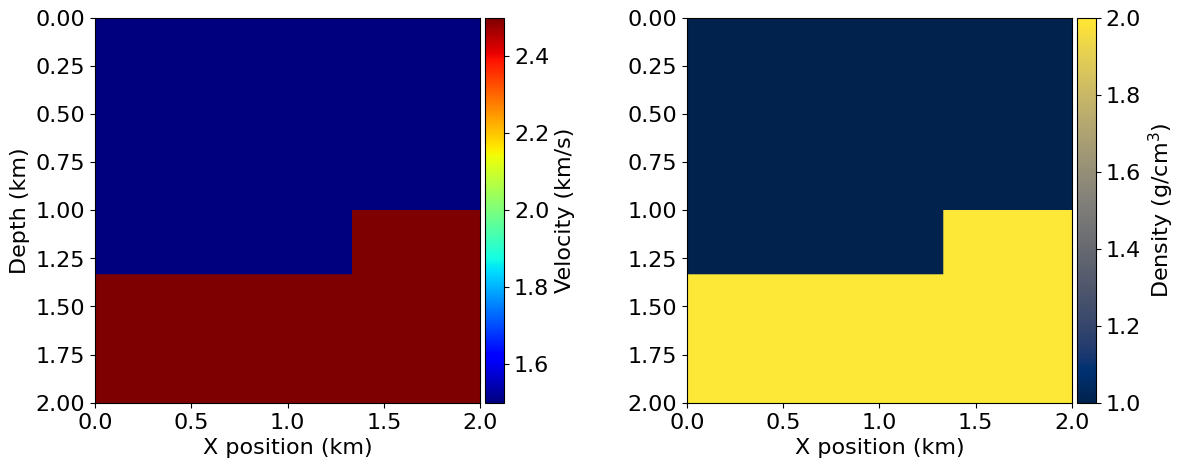

In [7]:
plot_model(model)

## Parâmetros da aquisição

### Tempo de aquisição

O período de aquisição inicia em $t_0 = 0$ $\mathrm{ms}$ e termina em $t_n = 1000$ $\mathrm{ms}$. 

O comprimento do passo temporal, $\Delta t$, foi escolhido a partir da condição de estabilidade:
$$
\begin{aligned}
    \Delta t &\le \frac{1}{\max(v_P)\sqrt{\dfrac{1}{\Delta x^2} + \dfrac{1}{\Delta z^2}}}\\
        &= \frac{1}{2500\ \mathrm{m/s} \sqrt{\dfrac{1}{(5\ \mathrm{m})^2} + \dfrac{1}{(5\ \mathrm{m})^2}}}\\
        &\approx 1.4142\ \mathrm{ms}
\end{aligned}
$$
Com base nisto, o comprimento do passo temporal escolhido foi $\Delta t = 1.0\ \mathrm{ms}$.

In [8]:
t0 = 0.  # ms
tn = 1500. # ms
dt = 1.0

### Geometria

Será utilizada uma fonte Ricker, que é parametrizada com uma frequência de pico $f_0 \approx \dfrac{f_{\max}}{3} = 20\ \mathrm{Hz}$.

In [9]:
# Frequência de pico da fonte
f0 = 0.020

In [10]:
zero_coords = np.array([[0,0]], dtype=model.dtype) # Para zerar as coordenadas da fonte e dos receptores da geometria.
geometry = AcquisitionGeometry(model, zero_coords, zero_coords, t0, tn)
geometry.resample(dt)

time_range = geometry.time_axis

In [11]:
src = RickerSource(name='src', grid=model.grid, f0=f0,
                   npoint=1, time_range=time_range)

src.coordinates.data[0, 0] = 1 * 1e3 # x = 1 km
src.coordinates.data[0, 1] = 0 * 1e3 # z = 0 km

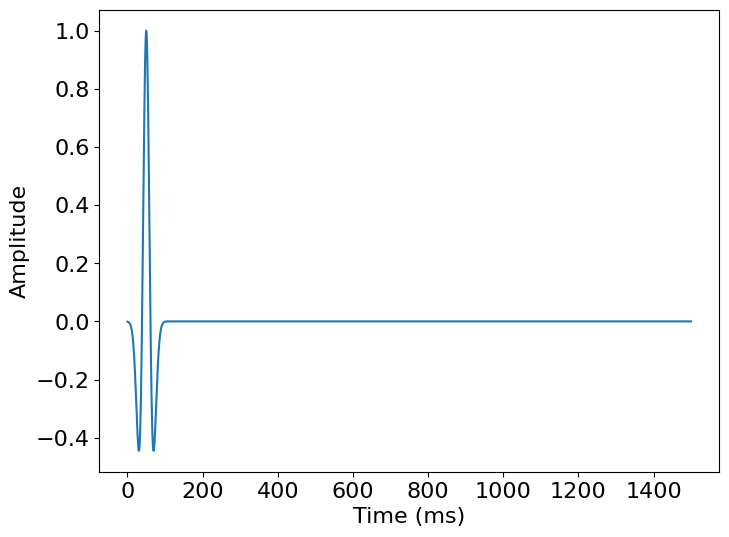

In [12]:
src.show() # Assinatura da fonte

Há um receptor para cada ponto da malha na superfície ($z = 0$). Logo, existem $n_{\mathrm{rec}} = 151$ receptores espaçados por $10$ $\mathrm{m}$

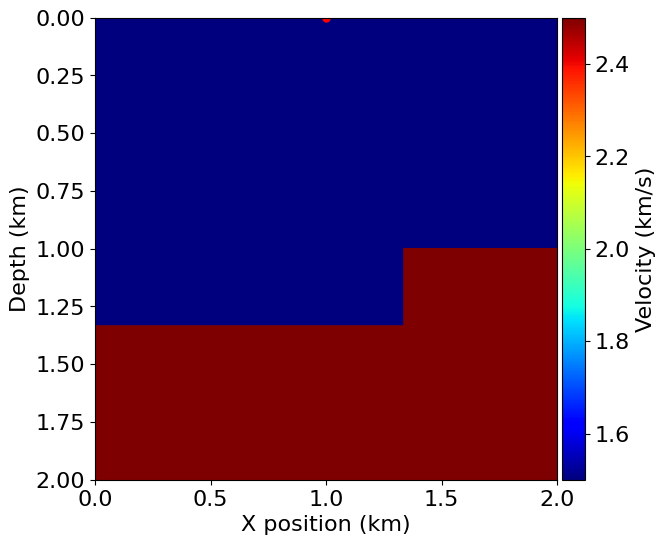

In [13]:
plot_velocity(model, source=src.coordinates.data)

### Definição da equação da onda acústica de 2ª ordem

Aqui é definida no *Devito* a equação

$$
\frac{1}{v_P^2}\frac{\partial^2 P}{\partial t^2} - \rho \nabla \cdot \left( \frac{1}{\rho} \nabla P \right) = S
$$

em que:

- $P$ é o campo de pressão;
- $v_P$ é o campo de velocidade da onda P;
- $\rho$ é o campo de densidade;
- $S$ é o termo fonte;

In [14]:
# Função pra o campo de pressão
P = TimeFunction(name="P", grid=model.grid, time_order=time_order, space_order=space_order, save=geometry.nt, staggered=NODE)

Trying to allocate more memory for symbol P than available on physical device, this will start swapping


In [15]:
vp = model.vp
rho = 1/model.b

In [16]:
# Equação da onda acústica de 2ª ordem
EDP = 1/vp**2 * P.dt2 - rho * div( 1/rho * grad(P, .5), -.5)
EDP

-(Derivative(b(x, y)*Derivative(P(time, x, y), x), x) + Derivative(b(x, y)*Derivative(P(time, x, y), y), y))/b(x, y) + Derivative(P(time, x, y), (time, 2))/vp(x, y)**2

In [17]:
# Expressão para o campo de ondas futuro, P(r, t + dt)
stencil = Eq(P.forward, solve(EDP, P.forward))
stencil

Trying to allocate more memory for symbol P than available on physical device, this will start swapping
Trying to allocate more memory for symbol P than available on physical device, this will start swapping
Trying to allocate more memory for symbol P than available on physical device, this will start swapping
Trying to allocate more memory for symbol P than available on physical device, this will start swapping


Eq(P(time + dt, x, y), dt**2*((Derivative(b(x, y)*Derivative(P(time, x, y), x), x) + Derivative(b(x, y)*Derivative(P(time, x, y), y), y))/b(x, y) - (-2.0*P(time, x, y)/dt**2 + P(time - dt, x, y)/dt**2)/vp(x, y)**2)*vp(x, y)**2)

Com base na expressão acima para o campo $P(\mathbf{x}, t + \Delta t)$, observa-se que o termo fonte deverá ter um coeficiente igual a $\Delta t^2 v_P^2$. Logo, a fonte $S$ deve ser injetada no campo de ondas futuro como $\Delta t^2 v_P^2 S(\mathbf{x}, t)$

In [18]:
# Símbolo do espaçamento temporal
s = model.grid.stepping_dim.spacing

# Expressão do termo fonte a ser injetada no stencil criado acima
src_term = src.inject(field=P.forward, expr=src * s**2 * model.vp**2)

Trying to allocate more memory for symbol P than available on physical device, this will start swapping


### Criação do operador de diferenças finitas

In [19]:
# Criação do operador do Devito
op = Operator([stencil] + src_term, subs=model.spacing_map)

Trying to allocate more memory for symbol P than available on physical device, this will start swapping
Trying to allocate more memory for symbol P than available on physical device, this will start swapping
Trying to allocate more memory for symbol P than available on physical device, this will start swapping
Trying to allocate more memory for symbol P than available on physical device, this will start swapping
Trying to allocate more memory for symbol P than available on physical device, this will start swapping
Trying to allocate more memory for symbol P than available on physical device, this will start swapping
Trying to allocate more memory for symbol P than available on physical device, this will start swapping
Trying to allocate more memory for symbol P than available on physical device, this will start swapping
Trying to allocate more memory for symbol P than available on physical device, this will start swapping
Trying to allocate more memory for symbol P than available on ph

In [20]:
# Execução
op(dt=dt)

PerformanceSummary([(PerfKey(name='section0', rank=None),
                     PerfEntry(time=6.130909999999994, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])),
                    (PerfKey(name='section1', rank=None),
                     PerfEntry(time=0.002004999999999984, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[]))])

# Resolução da alternativa a) Plotagem do campo de ondas

In [21]:
def plot_wavefield(u, geometry, src_pos, model, title=None, t0=0, tn=-1, rec_pos=None, annotation_callback=None):
    """
    Exibe o campo de onda em 4 instantes distribuídos em um período determinado por `t0` e `tn`
    """
    shape_pad = np.array(model.shape)
    origin_pad = origin
    extent_pad = tuple([s*(n-1) for s, n in zip(spacing, shape_pad)])

    # Note: flip direction of second dimension to make the plot positive downwards
    plt_extent = [origin_pad[0], origin_pad[0] + extent_pad[0],
                origin_pad[1] + extent_pad[1], origin_pad[1]]
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharex=True)
    fig.suptitle(title, size=20, y=1.05)
    isfirst = True
    last_ax = None
    last_plot = None

    t0 = t0 - geometry.t0
    tn = tn - geometry.t0

    snapshots = None
    if tn < 0:
        idx_min = max(int(np.round(t0/dt)), 0)
        snapshots = np.linspace(idx_min, geometry.nt - 1, num=4, dtype=np.int32)
    else:
        idx_min = max(int(np.round(t0/dt)), 0)
        idx_max = min(int(np.round(tn/dt)), geometry.nt - 1)
        snapshots = np.linspace(idx_min, idx_max, num=4, dtype=np.int32)


    udata = u.data
    amax = np.max(np.abs(udata[geometry.nt-1, :, :]))

    for count, ax in enumerate(axes.ravel()):
        snapshot = snapshots[count]
        last_plot = ax.imshow(udata[snapshot, model.nbl:-model.nbl, model.nbl:-model.nbl].T,
                              cmap="seismic", vmin=-amax,
                  vmax=+amax, extent=plt_extent)
        ax.plot(src_pos[0], src_pos[1], 'red', linestyle='None', marker='*',
                markersize=8, label="Source")
        
        if type(rec_pos) != type(None):
            ax.plot(rec_pos[0], rec_pos[1], 'green', linestyle='None', marker='v',
                    markersize=8, label="Receiver")

        domain_size = np.array(model.domain_size)
        ax.plot([model.origin[0], 2/3*domain_size[0], 2/3*domain_size[0], domain_size[0]],
                [2/3*domain_size[1], 2/3*domain_size[1], 1/2*domain_size[1], 1/2*domain_size[1]], ls='dashed', color='orange')
            
        ax.grid()
        ax.tick_params('both', length=4, width=0.5, which='major', labelsize=11)

        ax.set_title("t=%.2fms" % (snapshot*dt + geometry.t0), fontsize=12)
        ax.set_xlabel("x (m)", fontsize=12)
        isfirst and ax.set_ylabel("z (m)", fontsize=12)
        isfirst = False
        last_ax = ax

    divider = make_axes_locatable(last_ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(last_plot, cax=cax)

    if annotation_callback:
        annotation_callback(fig, axes)

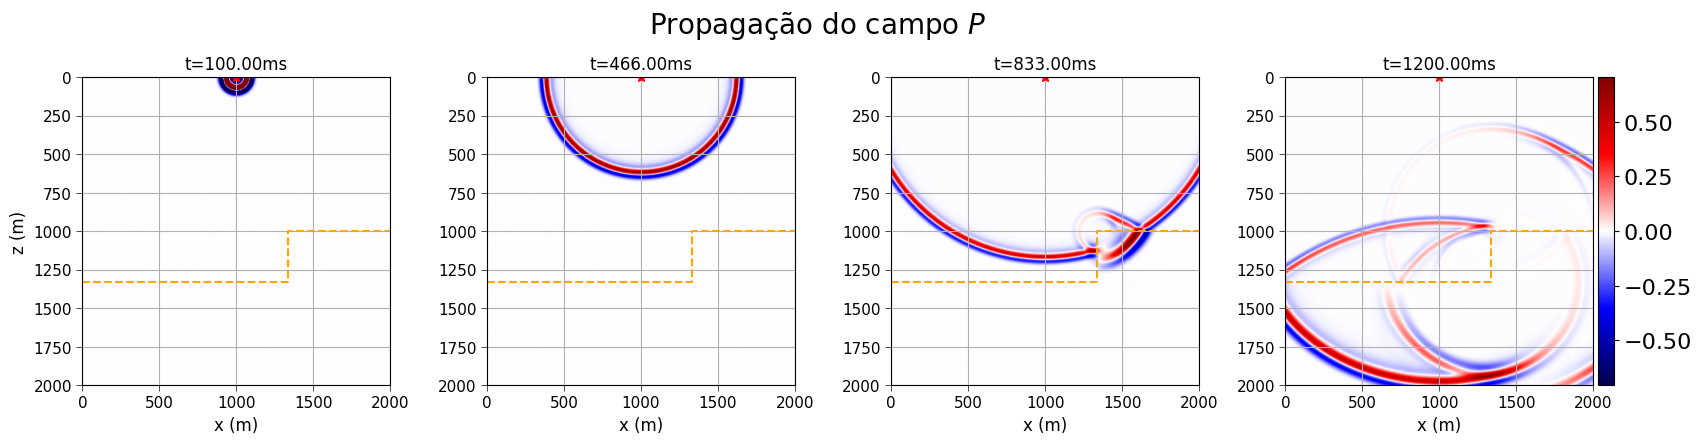

In [22]:
plot_wavefield(P, geometry, src.coordinates.data[0], model, 'Propagação do campo $P$', t0=100, tn=1200)

# Resolução da alternativa b)

In [23]:
def annotation_callback(fig, axes):
    snap900 = axes[0]
    snap1000 = axes[1]
    snap1200 = axes[3]

    arrowprops={'width': 5}
    
    snap900.annotate('Incidente', (250, 1000), (250, 500), arrowprops=arrowprops)
    snap900.annotate('Difratada', (1300, 750), (1300, 200), arrowprops=arrowprops)
    
    snap1000.annotate('Refratada', (1800, 800), (1000, 1700), arrowprops=arrowprops)

    snap1200.annotate('Transmitida', (400, 1750), (400, 1250), arrowprops=arrowprops)
    snap1200.annotate('Refletida', (750, 900), (750, 500), arrowprops=arrowprops)
    
    

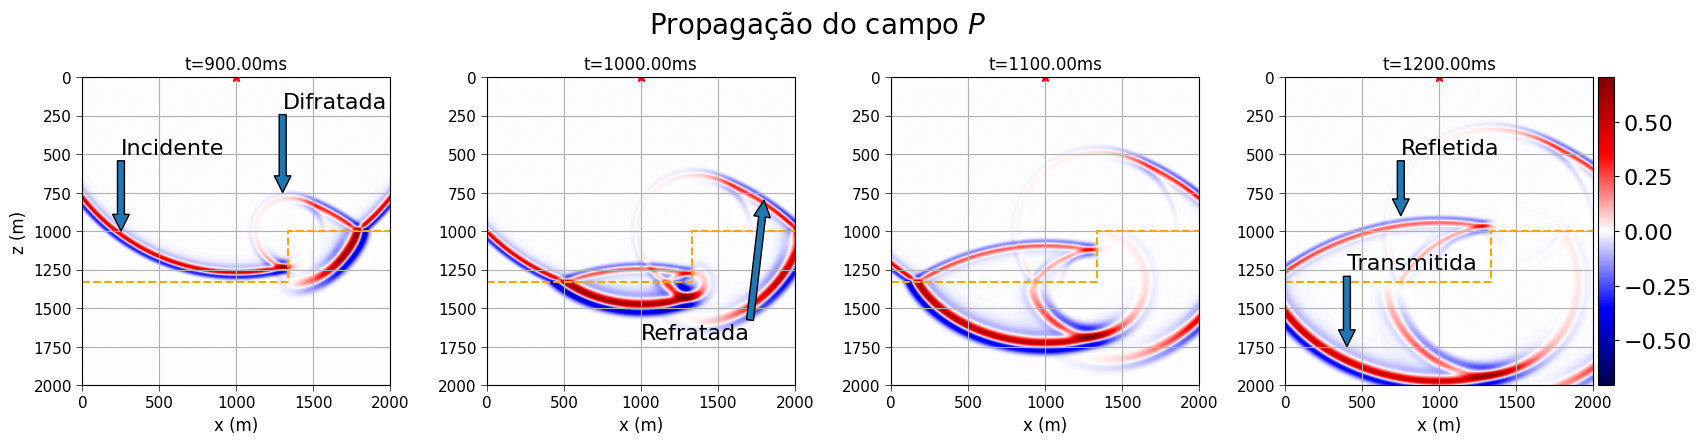

: 

In [ ]:
plot_wavefield(P, geometry, src.coordinates.data[0], model, 'Propagação do campo $P$', t0=900, tn=1200, annotation_callback=annotation_callback)

A onda difratada ($t=900\ \mathrm{ms}$) foi gerada pela quina entre as duas camadas, que serve como um ponto de difração devido às suas dimensões reduzidas.

A onda refratada ($t=1000\ \mathrm{ms}$) foi identificada pela *head wave* e devido ao fato de que esta começa a aparecer a partir da coordenada horizontal
$$
s_x + \frac{v_{P1} h}{\sqrt{v_{P2}^2 - v_{P1}^2}} = 1\ \mathrm{km} + \frac{1.5\ \mathrm{km/s} \times 1.0\ \mathrm{km}}{\sqrt{(2.5\ \mathrm{km/s})^2 - (1.5\ \mathrm{km/s})^2}} = 1.75\ \mathrm{km}
$$
no caso da região mais elevada, em que $s_x = 1.0\ \mathrm{km}$ é a coordenada horizontal da fonte e $h = 1.0\ \mathrm{km}$ é a profundidade da região mais elevada da segunda camada.

A onda transmitida foi identificada pelo fato de que sua frente de onda está se propagando na segunda camada.

A onda refletida foi identificada pelo fato de que sua frente de onda está se propagando na primeira camada em direção à fonte.